- 3 subt params
- 2 pf params

In [1]:
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt

import pandas as pd
import seaborn as sns
import os

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

from scipy.stats import zscore

import statsmodels.api as sm
from statsmodels.stats.multitest import fdrcorrection

# !pip install scikit-bio

In [3]:
from skbio.stats.distance import mantel
%matplotlib inline

In [4]:
# mixed_batch_data = pd.read_csv('/content/drive/MyDrive/curvefit_traits_merged_linearpf_onlyneccols.csv', index_col='subID')
mixed_batch_data = pd.read_csv('../../data/subtlety_playfight_data/curvefit_traits_merged_linearpf_onlyneccols_fight.csv', index_col='subID')
mixed_batch_data.drop('Unnamed: 0', axis=1, inplace=True)
mixed_batch_data

,PSE_subt,range_subt,bias_subt,sigma_subt,PSE_pf,slope_pf,range_pf,bias_pf,social_skill,attn_switch,...,comm,posAffect,negAffect,neuroticism,extraversion,openness,agreeableness,conscientiousness,loneliness,nfriends
subID,,,,,,,,,,,,,,,,,,,,,
30002.0,0.552951,0.900821,0.315504,0.103360,0.513054,0.784286,0.784286,0.452539,21.0,23.0,...,16.000000,20.0,0.0,38.0,28.000000,31.000000,34.0,39.0,56.0,3.0
30004.0,0.276896,0.805834,0.999458,0.076866,0.872907,0.469286,0.469286,0.170256,21.0,20.0,...,15.000000,25.0,11.0,38.0,26.181818,50.000000,50.0,46.0,56.0,3.0
30005.0,0.320583,0.710131,0.861730,0.115353,0.501696,0.842143,0.842143,0.490950,17.0,29.0,...,16.000000,20.0,21.0,51.0,39.000000,40.000000,43.0,19.0,41.0,5.0
30006.0,0.464823,0.989396,0.889572,0.079221,0.741046,0.674587,0.674587,0.000307,8.0,10.0,...,3.000000,25.0,0.0,18.0,41.000000,31.000000,44.0,57.0,30.0,4.0
30008.0,0.325118,0.582252,0.692710,0.172585,0.677591,0.511071,0.511071,0.314366,5.0,15.0,...,12.222222,28.0,4.0,27.0,46.000000,42.545455,46.0,50.0,45.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30344.0,0.361233,0.655715,0.794480,0.135840,0.492859,0.566786,0.566786,0.509343,27.0,18.0,...,16.000000,14.0,0.0,25.0,29.000000,49.000000,35.0,56.0,41.0,6.0
30345.0,0.475067,0.833333,1.000000,0.013915,0.639965,0.781136,0.781136,0.000457,15.0,14.0,...,5.000000,15.0,15.0,36.0,23.000000,37.000000,45.0,54.0,72.0,1.0
30346.0,0.426850,0.999914,0.961644,0.045409,0.412504,0.786429,0.786429,0.822185,16.0,25.0,...,8.000000,27.0,6.0,49.0,36.000000,36.000000,43.0,44.0,56.0,3.0


In [5]:
mixed_batch_data.isna().sum()

PSE_subt             0
range_subt           0
bias_subt            0
sigma_subt           0
PSE_pf               0
slope_pf             0
range_pf             0
bias_pf              0
social_skill         0
attn_switch          0
img                  0
attn_to_det          0
comm                 0
posAffect            0
negAffect            0
neuroticism          0
extraversion         0
openness             0
agreeableness        0
conscientiousness    0
loneliness           0
nfriends             1
dtype: int64

Looks like one subject is missing a value for `nfriends`. Let's just drop them as this will cause headaches later

In [6]:
mixed_batch_data = mixed_batch_data.dropna()
mixed_batch_data.shape

(274, 22)

In [7]:
mixed_batch_data.columns

Index(['PSE_subt', 'range_subt', 'bias_subt', 'sigma_subt', 'PSE_pf',
       'slope_pf', 'range_pf', 'bias_pf', 'social_skill', 'attn_switch', 'img',
       'attn_to_det', 'comm', 'posAffect', 'negAffect', 'neuroticism',
       'extraversion', 'openness', 'agreeableness', 'conscientiousness',
       'loneliness', 'nfriends'],
      dtype='object')

In [8]:
curve_param_cols = [
                  'PSE_subt',
                  'range_subt',
                  'bias_subt',
                  'range_pf',
                  'bias_pf'
                    ]
subt_param_cols = [
                  'PSE_subt',
                  'range_subt',
                  'bias_subt',
                   ]
pf_param_cols = [
                 'range_pf',
                 'bias_pf'
                 ]
trait_cols = [
              'social_skill', 'attn_switch', 'img', 'attn_to_det', 'comm',
              'posAffect',
              'negAffect',
              'neuroticism', 'extraversion', 'openness', 'agreeableness', 'conscientiousness',
              'loneliness',
              'nfriends'
       ]

social_cols = [
              'social_skill', 'attn_switch', 'img', 'attn_to_det', 'comm',
              'loneliness',
              'nfriends'
              ]
personality_cols = [
                    'posAffect',
                    'negAffect',
                    'neuroticism', 'extraversion', 'openness', 'agreeableness', 'conscientiousness',
              ]

In [9]:
results_loc= '../../results/subtlety_playfight_mixed/trait-beh/'

In [10]:
# cmap = 'BrBG'

In [11]:
df_range_traits = pd.DataFrame(data=[[i,mixed_batch_data[i].min(),mixed_batch_data[i].max()] for i in trait_cols],columns=['trait','min','max'])
df_range_traits

,trait,min,max
0,social_skill,1.0,29.0
1,attn_switch,4.0,29.0
2,img,0.0,25.0
3,attn_to_det,3.0,28.0
4,comm,0.0,26.0
5,posAffect,0.0,40.0
6,negAffect,0.0,33.0
7,neuroticism,12.0,59.0
8,extraversion,13.0,55.0
9,openness,21.0,57.0


In [12]:
df_range_traits['ticks'] = [[0,10,20,29],[0,10,20,29],[0,10,20,29],[0,10,20,29],[0,10,20,29],\
    [0,10,20,30,40],[0,10,20,30,40], [0,20,40,60], [0,20,40,60], [0,20,40,60], [0,20,40,60], [0,20,40,60], [0,20,40,60,80],[0,10,20]]

df_range_traits['tickends'] = [[0,29],[0,29],[0,29],[0,29],[0,29],\
        [0,40],[0,40], 
        [0,60],[0,60], [0,60], [0,60], [0,60],
        [0,80],
        [0,20]]
df_range_traits

,trait,min,max,ticks,tickends
0,social_skill,1.0,29.0,"[0, 10, 20, 29]","[0, 29]"
1,attn_switch,4.0,29.0,"[0, 10, 20, 29]","[0, 29]"
2,img,0.0,25.0,"[0, 10, 20, 29]","[0, 29]"
3,attn_to_det,3.0,28.0,"[0, 10, 20, 29]","[0, 29]"
4,comm,0.0,26.0,"[0, 10, 20, 29]","[0, 29]"
5,posAffect,0.0,40.0,"[0, 10, 20, 30, 40]","[0, 40]"
6,negAffect,0.0,33.0,"[0, 10, 20, 30, 40]","[0, 40]"
7,neuroticism,12.0,59.0,"[0, 20, 40, 60]","[0, 60]"
8,extraversion,13.0,55.0,"[0, 20, 40, 60]","[0, 60]"
9,openness,21.0,57.0,"[0, 20, 40, 60]","[0, 60]"


In [13]:
df_range_traits['abbr'] = ['soc', 'attn', 'img','det', 'comm', 'pos', 'neg', 'N', 'E', 'O', 'A', 'C', 'UCLA', '# fr.']
df_range_traits

,trait,min,max,ticks,tickends,abbr
0,social_skill,1.0,29.0,"[0, 10, 20, 29]","[0, 29]",soc
1,attn_switch,4.0,29.0,"[0, 10, 20, 29]","[0, 29]",attn
2,img,0.0,25.0,"[0, 10, 20, 29]","[0, 29]",img
3,attn_to_det,3.0,28.0,"[0, 10, 20, 29]","[0, 29]",det
4,comm,0.0,26.0,"[0, 10, 20, 29]","[0, 29]",comm
5,posAffect,0.0,40.0,"[0, 10, 20, 30, 40]","[0, 40]",pos
6,negAffect,0.0,33.0,"[0, 10, 20, 30, 40]","[0, 40]",neg
7,neuroticism,12.0,59.0,"[0, 20, 40, 60]","[0, 60]",N
8,extraversion,13.0,55.0,"[0, 20, 40, 60]","[0, 60]",E
9,openness,21.0,57.0,"[0, 20, 40, 60]","[0, 60]",O


In [14]:
df_range_beh = pd.DataFrame(data=[[i,mixed_batch_data[i].min(),mixed_batch_data[i].max()] for i in curve_param_cols],columns=['param','min','max'])
df_range_beh['ylabel'] = [i.split('_')[0] for i in df_range_beh['param']]
df_range_beh

,param,min,max,ylabel
0,PSE_subt,0.000000,0.729328,PSE
1,range_subt,0.200238,1.000000,range
2,bias_subt,0.105735,1.000000,bias
3,range_pf,0.014257,0.999900,range
4,bias_pf,0.000101,1.000000,bias


In [15]:
s=16 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=s) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

PSE 3
range 5
bias 4
range 5
bias 4


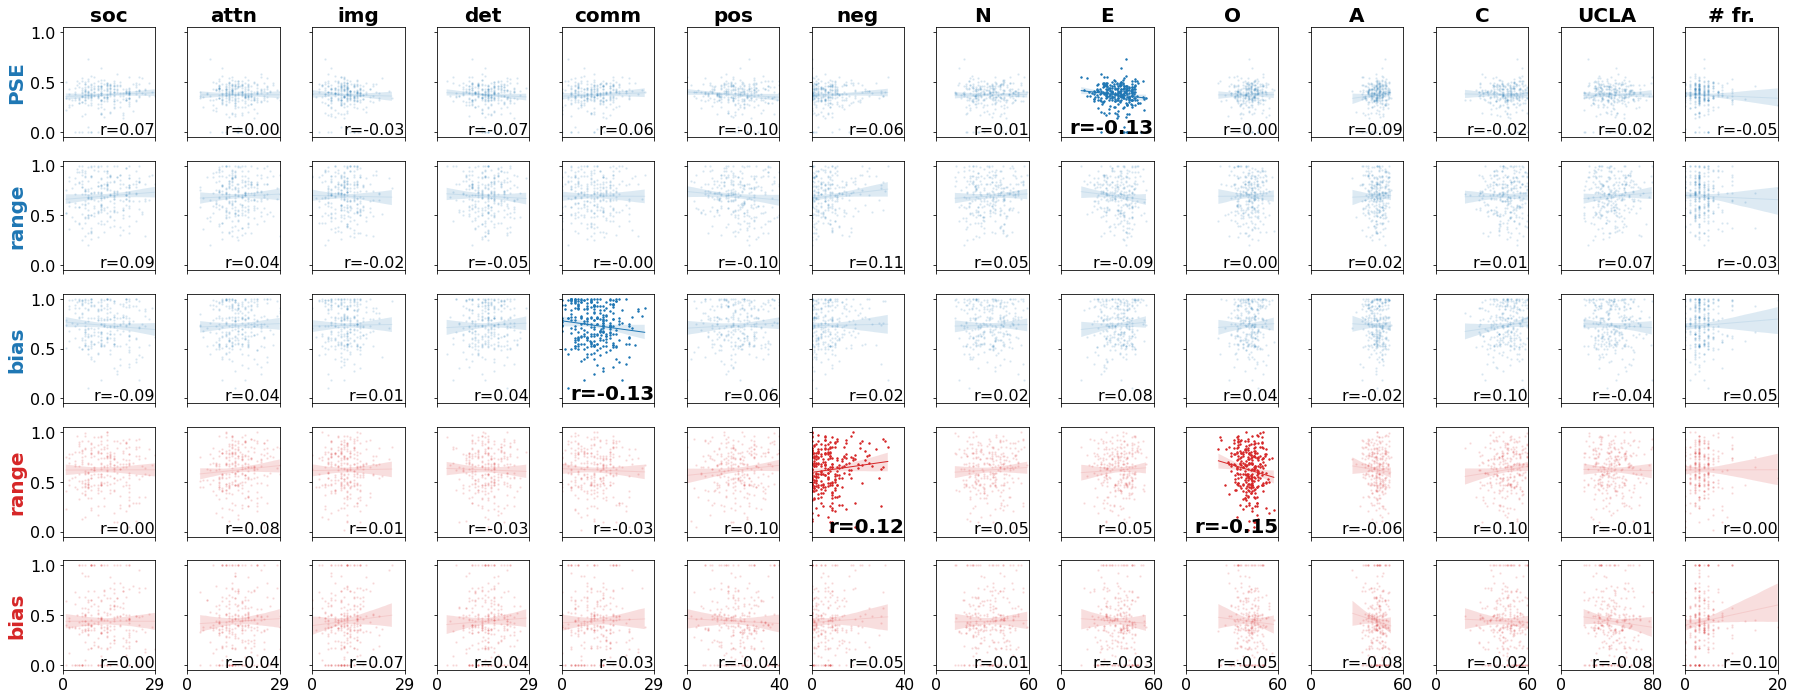

In [16]:
fig, axes = plt.subplots(nrows=len(curve_param_cols), ncols = len(trait_cols), figsize=(25,10),sharey=True,sharex='col')

all_ps = []

for i,param in enumerate(curve_param_cols):
    for j,trait in enumerate(trait_cols):
        x = trait
        y = param
        r, p = sp.stats.pearsonr(mixed_batch_data[x], mixed_batch_data[y])
        all_ps.append(p)

        if p < 0.05:
            # color = 'black'
            weight = 'bold'
            alpha = 1
            fontsize = 20
            linewidth = 1
        else:
            # color = 'gray'
            weight = None
            alpha = .1
            fontsize = 16
            linewidth = 1

        if i <= 2:
            color = 'tab:blue'
        else:
            color = 'tab:red'


        sns.regplot(data=mixed_batch_data, x=x, y=y, ax=axes[i,j], color=color, scatter_kws={'s':2,'alpha':alpha},line_kws={'alpha': alpha, 'linewidth' : linewidth})
        
        axes[i,j].annotate(f'r={r:.2f}', xy=(1, 0), xycoords = 'axes fraction', weight = weight,fontsize=fontsize,va='bottom',ha='right')

        axes[i,j].set_xlabel('') 
        
        if j == 0:
            ylabel = df_range_beh.loc[df_range_beh['param']==param,'ylabel'].values[0]
            print(ylabel, len(ylabel))
            axes[i,j].set_ylabel(ylabel, fontsize=20,color=color,fontweight='bold')
        else:
            axes[i,j].set_ylabel('')

        if i == 0:
            title = df_range_traits.loc[df_range_traits['trait']==trait,'abbr'].values[0]
            axes[i,j].set_title(title, fontweight='bold',color='k',fontsize=20)
        else:
            axes[i,j].set_title('')
        
        row = df_range_traits['trait'] == trait
        xmin,xmax = df_range_traits.loc[row,'min'].values[0],df_range_traits.loc[row,'max'].values[0]
        axes[i,j].set_xlim(xmin,xmax)
        axes[i,j].set_xticks(df_range_traits.loc[row,'tickends'].values[0])

fig.tight_layout()
plt.savefig(f'{results_loc}/trait_beh_all_scatter_long.png', dpi=300, bbox_inches='tight')

In [17]:
fdrcorrection(all_ps)

(array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False]),
 array([0.77209425, 0.99293779, 0.89606993, 0.81760699, 0.84061476,
        0.6992661 , 0.84061476, 0.94188737, 0.6992661 , 0.99293779,
        0.70081876, 0.93208284, 0.93208284, 0.84061476, 0.70081876,
        0.84061476, 0.94188737, 0.84061476, 0.99293779, 0.6992661 ,
        0.6992661 , 0.84061476, 0.70081876, 0.99293779, 0.94188737,
        0.97189965, 0.83042984, 0.89606993, 0.70081876, 0.89606993,
        0.94188737, 0.84061476, 0.69

In [17]:
# first, super important to z-score all the features in order to minimize the impact of different features being measured on different scales (just like PCA)
mixed_batch_data_zscored = mixed_batch_data.apply(zscore)

In [18]:
curve_param_cols

['PSE_subt', 'range_subt', 'bias_subt', 'range_pf', 'bias_pf']

In [20]:
# All curve params (both tasks), all traits
x = sp.spatial.distance.pdist(mixed_batch_data_zscored[curve_param_cols], 'euclidean')
y = sp.spatial.distance.pdist(mixed_batch_data_zscored[trait_cols], 'euclidean')
r, p, n = mantel(x, y, method='pearson', alternative='greater', permutations=5000)
print(f'r = {r:.3f}, p = {p:.3f}, n = {n}')
results_dict['both'] = (r, p)

r = 0.051, p = 0.048, n = 274


In [23]:
# Just subtlety params, all traits
x = sp.spatial.distance.pdist(mixed_batch_data_zscored[subt_param_cols], 'euclidean')
y = sp.spatial.distance.pdist(mixed_batch_data_zscored[trait_cols], 'euclidean')
r, p, n = mantel(x, y, method='pearson', alternative='greater', permutations=5000)
print(f'r = {r:.3f}, p = {p:.3f}, n = {n}')
results_dict['subt_only'] = (r, p)

r = 0.026, p = 0.200, n = 274


In [25]:
# Just playfight params, all traits
x = sp.spatial.distance.pdist(mixed_batch_data_zscored[pf_param_cols], 'euclidean')
y = sp.spatial.distance.pdist(mixed_batch_data_zscored[trait_cols], 'euclidean')
r, p, n = mantel(x, y, method='pearson', alternative='greater', permutations=5000)
print(f'r = {r:.3f}, p = {p:.3f}, n = {n}')
results_dict['pf_only'] = (r, p)

r = 0.046, p = 0.055, n = 274


In [26]:
results_df = pd.DataFrame.from_dict(results_dict, orient='index', columns=['r', 'p'])
results_df.index.name = 'task'
results_df

,r,p
task,,
both,0.051081,0.048190
subt_only,0.026162,0.199760
pf_only,0.046018,0.054789


In [27]:
s=16 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=s) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

0 Rectangle(xy=(-0.4, 0), width=0.8, height=0.0510811, angle=0)
bar.get_x(): -0.4
4 Rectangle(xy=(0.6, 0), width=0.8, height=0.0261623, angle=0)
bar.get_x(): 0.6
8 Rectangle(xy=(1.6, 0), width=0.8, height=0.0460179, angle=0)
bar.get_x(): 1.6


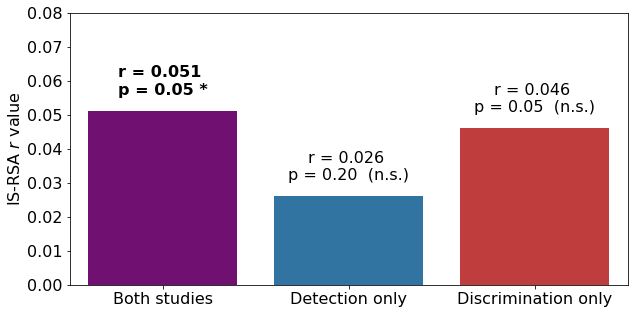

In [29]:
fig,axs = plt.subplots(nrows=1,ncols=1,figsize=(10,5))
plots = sns.barplot(dodge=False,
    x="task", 
    y="r", 
    data=results_df.reset_index(), 
    hue="task", 
    palette=['purple', 'tab:blue', 'tab:red'], 
 # Adjust this value to increase or decrease the bar width
)

count = -1
for b, bar in enumerate(plots.patches):
  if ~np.isnan(bar.get_height()):  # Ensure index doesn't go out of bounds
    count+=1
    print(b,bar)
    # annotate bar with r and p value
    r = results_df.iloc[count]['r']#[b, 0]
    p = results_df.iloc[count]['p']#[b, 1]

    print('bar.get_x():',bar.get_x())

    if p < 0.05:
      weight='bold'
      annot='*'
    else:
      weight=None
      annot=' (n.s.)'
      
    plots.annotate(f'r = {r:.3f} \np = {p:.2f} {annot}',
                    (bar.get_x() + bar.get_width() / 2,
                    bar.get_height()*1.01), ha='center', va='bottom',
                    size=16, xytext=(0, 12),
                    textcoords='offset points',
                    weight=weight)

plots.set_ylabel("IS-RSA $r$ value")
plots.set_ylim(0, 0.08)
plots.set_xlabel('')
xticks = plots.get_xticks()
# plots.legend(None)#bbox_to_anchor=[1.01,1])
plots.get_legend().remove()
plots.set_xticklabels(['Both studies','Detection only','Discrimination only'])
plt.savefig(f'{results_loc}/trait_beh_comparisons.png', dpi=300, bbox_inches='tight')